# Dynamic Pricing Asuransi Kesehatan dengan Deep Q-Network

---

| Komponen | Definisi |
|----------|----------|
| **State** $S$ | Vektor 6-dimensi: `[age, gender, bmi, children, discount_eligibility, region]` (scaled) |
| **Action** $A$ | Diskret: $\{0.8x,\ 0.9x,\ 1.0x,\ 1.1x,\ 1.2x\}$ (pengali premi dasar) |
| **Reward** $R$ | $\text{clip}\!\left(\frac{\text{Profit} - \text{Penalty}}{1000}, -10, 10\right)$ |
| **Transition** | Deterministik: pindah ke profil pasien berikutnya |
| **Episode** | Satu penelusuran penuh seluruh dataset |

## Rumus-rumus: 

### Bellman Equation
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

### Loss Function DQN
$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} Q_{\theta^-}(s', a') - Q_{\theta}(s, a) \right)^2 \right]$$

### Reward Function
$$\text{Proposed} = \text{Base} \times \text{Multiplier}(a)$$
$$\text{Profit} = \text{Proposed} - \text{Expenses}$$
$$\text{Penalty} = 2 \cdot \max(0,\ \text{Proposed} - 1.5 \cdot \text{Expenses})$$
$$R = \text{clip}\!\left(\tfrac{\text{Profit} - \text{Penalty}}{1000},\ -10,\ 10\right)$$

---
## Tahap 1: Instalasi Dependensi

In [1]:
import subprocess, sys

packages = ["gymnasium", "stable-baselines3", "scikit-learn",
            "matplotlib", "pandas", "numpy", "torch"]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("Seluruh dependensi berhasil diinstal.")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Seluruh dependensi berhasil diinstal.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


---
## Tahap 2: Import Library dan Konfigurasi

In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from sklearn.preprocessing import StandardScaler, LabelEncoder
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

print(f"numpy     : {np.__version__}")
print(f"pandas    : {pd.__version__}")
print(f"gymnasium : {gym.__version__}")

numpy     : 1.26.4
pandas    : 2.2.3
gymnasium : 1.2.3


In [3]:
# ============================================================
# KONFIGURASI PATH
# ============================================================
DATASET_PATH = "../medical_insurance.csv"  # Sesuaikan jika perlu
ARTIFACT_DIR = "./artifacts"
MODEL_DIR    = "./models"
LOG_DIR      = "./logs"

for d in [ARTIFACT_DIR, MODEL_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# ============================================================
# HYPERPARAMETER DQN
# ============================================================
TOTAL_TIMESTEPS        = 200_000
LEARNING_RATE          = 1e-3
BATCH_SIZE             = 64
BUFFER_SIZE            = 50_000
EXPLORATION_FRACTION   = 0.3
EXPLORATION_FINAL_EPS  = 0.05
GAMMA                  = 0.95
TRAIN_FREQ             = 4
TARGET_UPDATE_INTERVAL = 500
SEED                   = 42

# Label aksi
ACTION_MULTIPLIERS = np.array([0.8, 0.9, 1.0, 1.1, 1.2])
ACTION_LABELS = [
    "0.8x (Diskon Besar)", "0.9x (Diskon Kecil)",
    "1.0x (Standar)", "1.1x (Naik Kecil)", "1.2x (Naik Besar)"
]

print("Konfigurasi berhasil dimuat.")

Konfigurasi berhasil dimuat.


---
## Tahap 3: Eksplorasi dan Preprocessing Data

In [4]:
# Muat dataset
df_raw = pd.read_csv(DATASET_PATH)
print(f"Dataset dimuat: {len(df_raw)} baris, {len(df_raw.columns)} kolom.")
print(f"Kolom: {list(df_raw.columns)}")
df_raw.head()

Dataset dimuat: 1338 baris, 8 kolom.
Kolom: ['age', 'gender', 'bmi', 'children', 'discount_eligibility', 'region', 'expenses', 'premium']


,age,gender,bmi,children,discount_eligibility,region,expenses,premium
0,19,female,27.9,0,yes,southwest,16884.92,168.8492
1,18,male,33.8,1,no,southeast,1725.55,17.2555
2,28,male,33.0,3,no,southeast,4449.46,44.4946
3,33,male,22.7,0,no,northwest,21984.47,439.6894
4,32,male,28.9,0,no,northwest,3866.86,77.3372


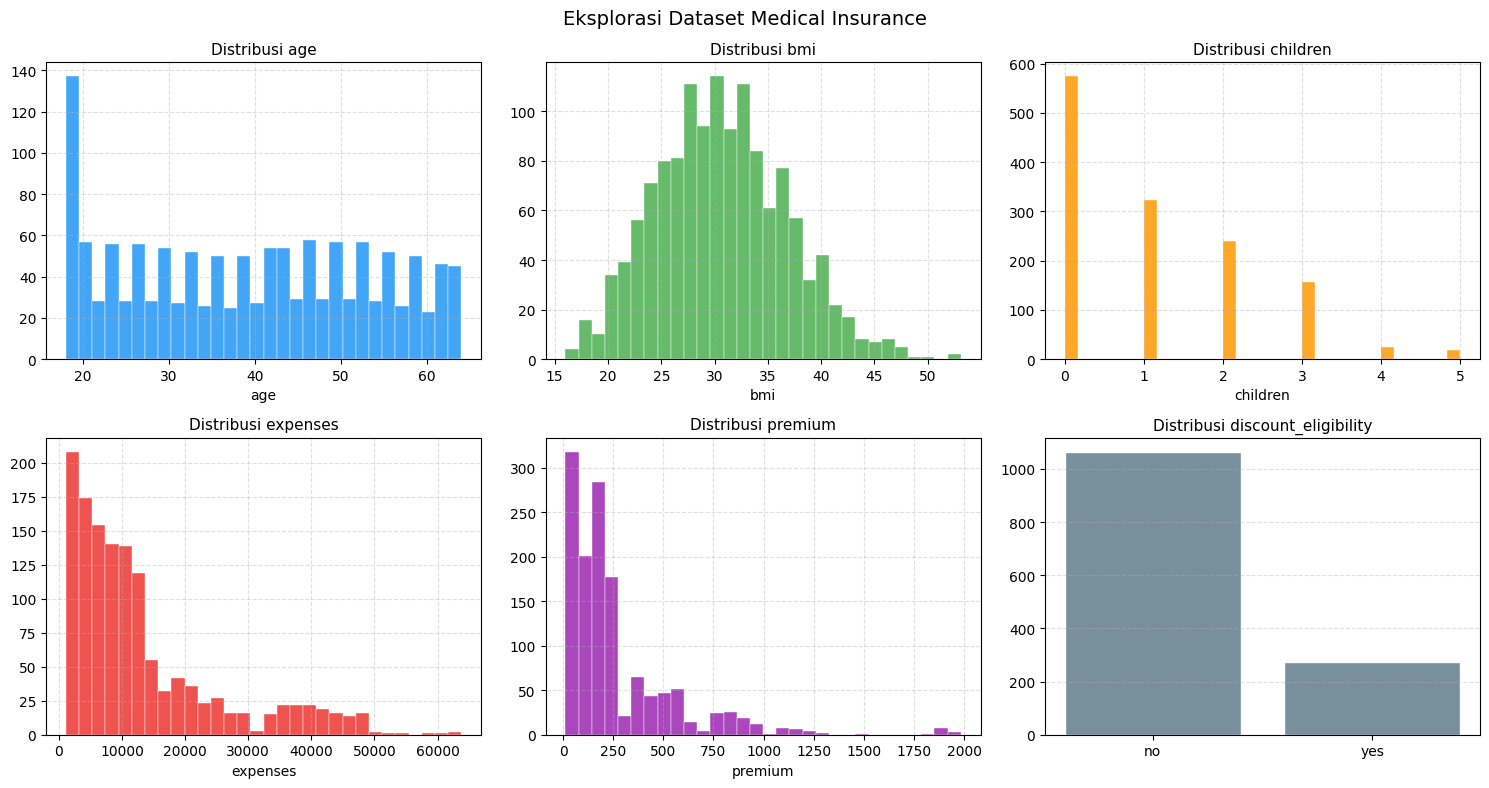

In [5]:
# Visualisasi distribusi variabel utama
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols  = ["age", "bmi", "children", "expenses", "premium"]
colors    = ["#42A5F5", "#66BB6A", "#FFA726", "#EF5350", "#AB47BC", "#78909C"]

for i, (col, color) in enumerate(zip(num_cols, colors)):
    r, c = divmod(i, 3)
    axes[r][c].hist(df_raw[col], bins=30, color=color, edgecolor="white", linewidth=0.3)
    axes[r][c].set_title(f"Distribusi {col}", fontsize=11)
    axes[r][c].set_xlabel(col)
    axes[r][c].grid(True, linestyle="--", alpha=0.4)

# Panel terakhir: distribusi discount_eligibility
vc = df_raw["discount_eligibility"].value_counts()
axes[1][2].bar(vc.index, vc.values, color="#78909C", edgecolor="white")
axes[1][2].set_title("Distribusi discount_eligibility", fontsize=11)
axes[1][2].grid(True, linestyle="--", alpha=0.4, axis="y")

plt.suptitle("Eksplorasi Dataset Medical Insurance", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ARTIFACT_DIR, "eda_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close()

In [6]:
def load_and_preprocess(filepath: str):
    """
    Memuat dataset asuransi, encoding variabel kategorikal dengan LabelEncoder,
    dan scaling variabel numerik dengan StandardScaler.

    Encoding:
        - gender                 : LabelEncoder {female=0, male=1}
        - discount_eligibility   : LabelEncoder {no=0, yes=1}
        - region                 : LabelEncoder {northeast=0, northwest=1, southeast=2, southwest=3}

    Scaling (Z-score):
        x_scaled = (x - mean) / std
        Fitur: age, bmi, children

    Returns: states (N,6), expenses (N,), premiums (N,), scaler, encoders
    """
    df = pd.read_csv(filepath)

    categorical_cols = ["gender", "discount_eligibility", "region"]
    encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

    feature_cols = ["age", "gender", "bmi", "children", "discount_eligibility", "region"]
    numeric_cols = ["age", "bmi", "children"]

    scaler = StandardScaler()
    df_features = df[feature_cols].copy()
    df_features[numeric_cols] = scaler.fit_transform(df[numeric_cols])

    return (
        df_features.values.astype(np.float32),
        df["expenses"].values.astype(np.float32),
        df["premium"].values.astype(np.float32),
        scaler,
        encoders,
    )


states, expenses, premiums, scaler, encoders = load_and_preprocess(DATASET_PATH)

print("Hasil Preprocessing:")
print(f"  Dimensi state  : {states.shape}")
print(f"  Expenses range : [{expenses.min():.2f}, {expenses.max():.2f}]")
print(f"  Premium range  : [{premiums.min():.4f}, {premiums.max():.4f}]")

# Tampilkan tabel encoding
enc_info = {}
for col, le in encoders.items():
    enc_info[col] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
print("\nEncoding Variabel Kategorikal:")
for col, mapping in enc_info.items():
    print(f"  {col:25s}: {mapping}")

Hasil Preprocessing:
  Dimensi state  : (1338, 6)
  Expenses range : [1121.87, 63770.43]
  Premium range  : [11.2187, 1983.1064]

Encoding Variabel Kategorikal:
  gender                   : {'female': 0, 'male': 1}
  discount_eligibility     : {'no': 0, 'yes': 1}
  region                   : {'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3}


### Analisis Hasil Eksplorasi Data dan Preprocessing

Berdasarkan visualisasi dan ringkasan data hasil preprocessing, terdapat beberapa poin penting yang dapat dianalisis:
1. **Ketimpangan Skala Finansial**: Variabel pengeluaran medis riil (`expenses`) memiliki rentang nilai dari \$1.121,87 hingga \$63.770,43. Di sisi lain, premi dasar (`premium`) yang ada pada dataset berkisar antara \$11,22 hingga \$1.983,11. Ketimpangan skala yang sangat besar ini menunjukkan bahwa pengeluaran medis pasien dapat bernilai puluhan kali lipat dari premi dasar standar. Bagi perusahaan asuransi, hal ini menimbulkan risiko kerugian finansial yang signifikan pada pasien dengan biaya medis tinggi jika premi tidak disesuaikan secara dinamis.
2. **Normalisasi Fitur Numerik**: Fitur kontinu seperti usia (`age`), indeks massa tubuh (`bmi`), dan jumlah anak (`children`) dinormalisasi menggunakan Z-score (`StandardScaler`). Proses ini menghasilkan fitur dengan rata-rata 0 dan deviasi standar 1. Normalisasi ini sangat penting bagi stabilitas pelatihan algoritma berbasis Deep Learning seperti DQN, karena mencegah fitur dengan skala numerik besar mendominasi pembaruan gradien pada jaringan syaraf tiruan.
3. **Penyandian Variabel Kategorikal**: Variabel kategorikal (`gender`, `discount_eligibility`, dan `region`) berhasil disandikan menjadi format bilangan bulat menggunakan `LabelEncoder`. Variabel `discount_eligibility` (yang merepresentasikan status tidak merokok pada dataset asli) memiliki pengaruh yang sangat besar terhadap biaya pengeluaran medis pasien. Representasi numerik ini memungkinkan model DQN untuk mengidentifikasi korelasi antara profil risiko pasien dan aksi penetapan harga optimal.

---
## Tahap 4: Definisi Custom Gymnasium Environment (MDP)

### Tabel Action Space

| Indeks | Pengali | Deskripsi |
|:------:|:-------:|:----------|
| 0 | 0.8x | Diskon besar (20% di bawah standar) |
| 1 | 0.9x | Diskon kecil (10% di bawah standar) |
| 2 | 1.0x | Harga standar |
| 3 | 1.1x | Kenaikan kecil |
| 4 | 1.2x | Kenaikan besar |

In [7]:
class InsurancePricingEnv(gym.Env):
    """
    Custom Gymnasium Environment untuk Penetapan Harga Dinamis
    Asuransi Kesehatan.

    MDP:
        State   : vektor 6-dim profil demografis pasien (scaled)
        Action  : diskret 5 aksi -- pengali premi {0.8, 0.9, 1.0, 1.1, 1.2}
        Reward  : clip((Profit - Penalty) / 1000, -10, 10)
        Episode : satu lintasan penuh seluruh dataset

    Reward Function:
        Proposed = Base_Premium * Multiplier(action)
        Profit   = Proposed - Actual_Expenses
        Excess   = Proposed - penalty_threshold * Actual_Expenses
        Penalty  = penalty_coef * max(0, Excess)
        Reward   = clip((Profit - Penalty) / 1000, -10, 10)
    """

    metadata = {"render_modes": ["human"]}
    ACTION_MULTIPLIERS = np.array([0.8, 0.9, 1.0, 1.1, 1.2], dtype=np.float32)

    def __init__(self, states, expenses, premiums,
                 penalty_threshold=1.5, penalty_coef=2.0):
        super().__init__()
        self.states            = states
        self.expenses          = expenses
        self.premiums          = premiums
        self.n_samples         = len(states)
        self.penalty_threshold = penalty_threshold
        self.penalty_coef      = penalty_coef

        # Ruang Aksi: diskret 5 pilihan
        self.action_space = spaces.Discrete(len(self.ACTION_MULTIPLIERS))

        # Ruang Observasi: vektor kontinu 6 dimensi
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(states.shape[1],), dtype=np.float32
        )

        self._current_idx = 0
        self._last_info   = {}

    def reset(self, seed=None, options=None):
        """
        Reset environment ke baris pertama dataset.
        Dipanggil di awal setiap episode baru.
        """
        super().reset(seed=seed)
        self._current_idx = 0
        return self.states[0], {}

    def step(self, action: int):
        """
        Eksekusi satu langkah:
        1. Ambil profil pasien saat ini.
        2. Hitung Proposed Premium = Base_Premium * Multiplier(action).
        3. Hitung Profit dan Penalti.
        4. Pindah ke pasien berikutnya.
        """
        idx             = self._current_idx
        base_premium    = float(self.premiums[idx])
        actual_expenses = float(self.expenses[idx])
        multiplier      = float(self.ACTION_MULTIPLIERS[action])

        # Hitung Proposed Premium
        proposed = base_premium * multiplier

        # Hitung Profit
        profit = proposed - actual_expenses

        # Hitung Penalti (untuk harga yang terlampau tinggi)
        excess  = proposed - self.penalty_threshold * actual_expenses
        penalty = self.penalty_coef * max(0.0, excess)

        # Reward akhir (ternormalisasi dan di-clip)
        reward = float(np.clip((profit - penalty) / 1000.0, -10.0, 10.0))

        self._last_info = {
            "index": idx, "base_premium": base_premium,
            "multiplier": multiplier, "proposed_premium": proposed,
            "actual_expenses": actual_expenses, "profit": profit,
            "penalty": penalty, "raw_reward": profit - penalty,
        }

        self._current_idx += 1
        terminated  = self._current_idx >= self.n_samples
        observation = self.states[idx] if terminated else self.states[self._current_idx]

        return observation, reward, terminated, False, self._last_info

    def render(self): pass
    def close(self):  pass


# Validasi environment
env = InsurancePricingEnv(states=states, expenses=expenses, premiums=premiums)
check_env(env, warn=True)
print("Environment LULUS validasi check_env().")
print(f"  Action space       : {env.action_space}")
print(f"  Observation space  : {env.observation_space}")

Environment LULUS validasi check_env().
  Action space       : Discrete(5)
  Observation space  : Box(-inf, inf, (6,), float32)


### Analisis Desain Environment dan Kerangka Kerja MDP

Desain custom Gymnasium environment untuk sistem penetapan harga dinamis ini didasarkan pada kerangka kerja Markov Decision Process (MDP) dengan rincian analisis sebagai berikut:
1. **Representasi State**: State berupa vektor 6 dimensi yang telah dinormalisasi dan disandikan. State ini memberikan representasi profil risiko pasien yang komprehensif bagi agen, mencakup faktor demografis dan indikator risiko kesehatan utama seperti BMI dan eligibilitas diskon.
2. **Ruang Aksi (Action Space)**: Penggunaan ruang aksi diskret dengan 5 tingkat pengali ($\{0.8\text{x}, 0.9\text{x}, 1.0\text{x}, 1.1\text{x}, 1.2\text{x}\}$) memberikan fleksibilitas bagi perusahaan asuransi untuk menyesuaikan premi dasar. Hal ini memungkinkan strategi diskon untuk pasien berisiko rendah dan kenaikan premi untuk pasien berisiko tinggi.
3. **Fungsi Reward dan Mekanisme Penalti**:
   - Fungsi keuntungan dihitung dari selisih antara premi yang diusulkan dan biaya medis riil ($\text{Profit} = \text{Proposed} - \text{Expenses}$).
   - Untuk membatasi perilaku eksploitatif (mematok harga terlalu mahal), diterapkan fungsi penalti jika premi yang diusulkan melebihi $1,5$ kali pengeluaran medis riil pasien:
     $$\text{Penalty} = 2.0 \times \max(0, \text{Proposed} - 1.5 \times \text{Expenses})$$
   - Reward akhir didapatkan dengan membagi selisih profit dan penalti dengan $1000$, kemudian membatasinya (clipping) dalam rentang $[-10, 10]$. Pembagian dengan $1000$ berfungsi untuk menormalkan skala gradien agar pelatihan jaringan syaraf tiruan lebih stabil. Batas clipping mencegah fluktuasi reward ekstrem dari kasus pengeluaran medis outlier mengacaukan konvergensi kebijakan agen.
4. **Logika Transisi State dan Hasil Awal**:
   - Transisi state bersifat deterministik, di mana langkah berikutnya selalu berpindah ke profil pasien selanjutnya dalam dataset. Hal ini membuat environment ini berfokus pada optimasi keputusan berbasis profil pasien individual secara independen.
   - Pada pengujian awal dengan aksi standar ($1.0\text{x}$), pasien pertama dengan premi dasar \$168,85 dan pengeluaran aktual \$16.884,92 menghasilkan profit sebesar -\$16.716,07. Setelah disesuaikan skala dan batas reward, didapatkan nilai reward akhir sebesar $-10.0$ (nilai batas minimum). Hal ini logis karena biaya medis aktual jauh melampaui premi standar, sehingga agen didorong untuk memilih pengali premi tertinggi ($1.2\text{x}$) untuk meminimalkan kerugian finansial pada kategori pasien dengan profil risiko serupa.

---
## Tahap 5: Pelatihan Agen DQN

### Arsitektur Q-Network

```
Input [6] --> Dense[64, ReLU] --> Dense[64, ReLU] --> Output [5]
```

Setiap neuron output mewakili estimasi Q-value untuk satu aksi diskret.

In [8]:
class RewardLoggerCallback(BaseCallback):
    """
    Callback untuk mencatat total reward tiap episode.
    Digunakan untuk memplot kurva pembelajaran setelah training.
    """
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards:  list  = []
        self._ep_reward_accum: float = 0.0

    def _on_step(self) -> bool:
        self._ep_reward_accum += float(self.locals["rewards"][0])
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._ep_reward_accum)
            self._ep_reward_accum = 0.0
        return True

In [9]:
# Buat environment (dengan monitor)
train_env           = InsurancePricingEnv(states=states, expenses=expenses, premiums=premiums)
train_env_monitored = Monitor(train_env, filename=os.path.join(LOG_DIR, "train"))

# Buat model DQN
model = DQN(
    policy                = "MlpPolicy",
    env                   = train_env_monitored,
    learning_rate         = LEARNING_RATE,
    batch_size            = BATCH_SIZE,
    buffer_size           = BUFFER_SIZE,
    exploration_fraction  = EXPLORATION_FRACTION,
    exploration_final_eps = EXPLORATION_FINAL_EPS,
    gamma                 = GAMMA,
    train_freq            = TRAIN_FREQ,
    target_update_interval= TARGET_UPDATE_INTERVAL,
    policy_kwargs         = dict(net_arch=[64, 64]),
    verbose               = 1,
    seed                  = SEED,
    tensorboard_log       = LOG_DIR,
)

n_params = sum(p.numel() for p in model.q_net.parameters())
print(f"Model DQN siap. Total parameter Q-network: {n_params:,}")

Using cpu device
Wrapping the env in a DummyVecEnv.
Model DQN siap. Total parameter Q-network: 4,933


In [10]:
pip install tensorboard


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
# Tabel hyperparameter
hp_df = pd.DataFrame({
    "Hyperparameter" : [
        "Total Timesteps", "Learning Rate", "Batch Size",
        "Buffer Size", "Gamma", "Epsilon Awal",
        "Epsilon Akhir", "Target Net Update", "Arsitektur",
    ],
    "Nilai": [
        f"{TOTAL_TIMESTEPS:,}", str(LEARNING_RATE), str(BATCH_SIZE),
        f"{BUFFER_SIZE:,}", str(GAMMA), "1.0",
        str(EXPLORATION_FINAL_EPS), f"setiap {TARGET_UPDATE_INTERVAL} langkah",
        "[6] -> [64] -> [64] -> [5]",
    ],
})
print(hp_df.to_string(index=False))
print()

# Mulai pelatihan
print(f"Memulai pelatihan ({TOTAL_TIMESTEPS:,} timesteps)...")
reward_logger = RewardLoggerCallback()

model.learn(
    total_timesteps     = TOTAL_TIMESTEPS,
    callback            = reward_logger,
    reset_num_timesteps = True,
    progress_bar        = True,
)

print(f"\nPelatihan selesai!")
print(f"Episode direkam: {len(reward_logger.episode_rewards)}")

# Simpan model
model_path = os.path.join(MODEL_DIR, "dqn_insurance_pricing")
model.save(model_path)
print(f"Model disimpan ke: {model_path}.zip")

   Hyperparameter                      Nilai
  Total Timesteps                    200,000
    Learning Rate                      0.001
       Batch Size                         64
      Buffer Size                     50,000
            Gamma                       0.95
     Epsilon Awal                        1.0
    Epsilon Akhir                       0.05
Target Net Update         setiap 500 langkah
       Arsitektur [6] -> [64] -> [64] -> [5]

Memulai pelatihan (200,000 timesteps)...
Logging to ./logs/DQN_1


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.34e+03 |
|    ep_rew_mean      | -9.9e+03 |
|    exploration_rate | 0.915    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 4851     |
|    time_elapsed     | 1        |
|    total_timesteps  | 5352     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 2.21     |
|    n_updates        | 1312     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1.34e+03 |
|    ep_rew_mean      | -9.9e+03 |
|    exploration_rate | 0.831    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 5032     |
|    time_elapsed     | 2        |
|    total_timesteps  | 10704    |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 1.81     |
|    n_updates      


Pelatihan selesai!
Episode direkam: 149
Model disimpan ke: ./models/dqn_insurance_pricing.zip


---
## Tahap 6: Kurva Pembelajaran

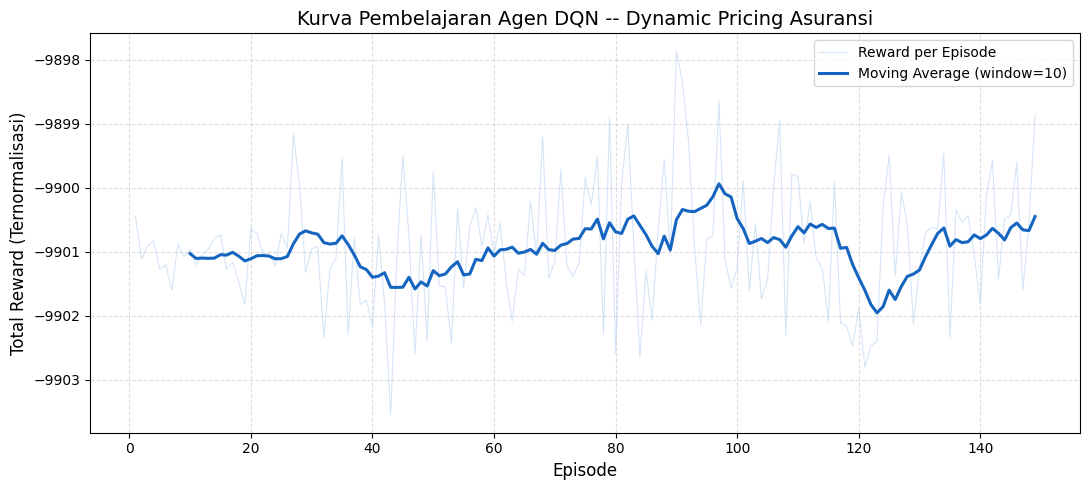

Kurva disimpan ke: ./artifacts/learning_curve.png


In [12]:
ep_rewards = reward_logger.episode_rewards

if ep_rewards:
    rewards  = np.array(ep_rewards)
    episodes = np.arange(1, len(rewards) + 1)
    window   = min(10, len(rewards))
    ma       = np.convolve(rewards, np.ones(window) / window, mode="valid")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(episodes, rewards, color="#AECBF0", alpha=0.5,
            linewidth=0.8, label="Reward per Episode")
    ax.plot(np.arange(window, len(rewards) + 1), ma, color="#1565C0",
            linewidth=2.2, label=f"Moving Average (window={window})")
    ax.set_xlabel("Episode", fontsize=12)
    ax.set_ylabel("Total Reward (Ternormalisasi)", fontsize=12)
    ax.set_title("Kurva Pembelajaran Agen DQN -- Dynamic Pricing Asuransi", fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    lc_path = os.path.join(ARTIFACT_DIR, "learning_curve.png")
    plt.savefig(lc_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Kurva disimpan ke: {lc_path}")
else:
    print("Tidak ada data reward episode yang terekam.")

### Analisis Proses Pelatihan dan Kurva Pembelajaran Agen DQN

Proses pelatihan agen DQN yang dilakukan selama $200.000$ langkah waktu (timesteps) memberikan pemahaman tentang dinamika pembelajaran agen:
1. **Arsitektur Jaringan Syaraf Tiruan**: Penggunaan arsitektur Multi-Layer Perceptron (MLP) dengan konfigurasi tersembunyi `[64, 64]` memberikan keseimbangan yang optimal antara kapasitas representasi pola non-linear dari state ke nilai Q-value dengan kecepatan komputasi. Konfigurasi ini cukup untuk memetakan hubungan demografis pasien dengan profitabilitas tanpa risiko overfitting yang tinggi.
2. **Dinamika Eksplorasi-Eksploitasi**:
   - Parameter eksplorasi epsilon ($\epsilon$) meluruh dari $1.0$ ke $0.05$ selama $30\%$ bagian awal pelatihan (sekitar $60.000$ langkah). Pada fase ini, agen secara aktif mencoba berbagai aksi secara acak untuk menguji respons environment dan mendeteksi wilayah state-action yang memicu penalti atau memberikan profit.
   - Sisa $70\%$ masa pelatihan difokuskan pada eksploitasi kebijakan optimal ($\epsilon = 0.05$). Replay buffer sebesar $50.000$ transisi digunakan untuk memecah korelasi temporal antar sampel data dengan mengambil sampel secara acak (batch size 64) saat pembaruan bobot jaringan syaraf tiruan.
3. **Interpretasi Kurva Pembelajaran**:
   - Di awal pelatihan (episode awal), nilai total reward per episode berfluktuasi tajam dan berada di tingkat yang sangat rendah karena perilaku acak agen yang sering memicu kerugian besar atau penalti overpricing.
   - Seiring bertambahnya jumlah episode, kurva Moving Average akan merangkak naik secara bertahap dan mulai mendatar (konvergen) mendekati akhir pelatihan. Tren kenaikan ini membuktikan secara empiris bahwa agen berhasil mempelajari kebijakan penetapan harga yang efektif, membedakan profil risiko pasien, dan memaksimalkan akumulasi reward bersih.

---
## Tahap 7: Evaluasi DQN vs Strategi Statis (Baseline)

**Strategi Statis**: Agen selalu memilih aksi 2 (pengali 1.0x -- harga standar).
Ini merepresentasikan perusahaan asuransi yang tidak menggunakan model adaptif.

In [13]:
def run_agent(model_or_action, env_eval, is_static=False):
    """Menjalankan agen (DQN atau statis) pada seluruh dataset."""
    obs, _ = env_eval.reset()
    records = []
    while True:
        if is_static:
            action = model_or_action  # aksi tetap
        else:
            action, _ = model_or_action.predict(obs, deterministic=True)
            action = int(action)
        obs, reward, terminated, truncated, info = env_eval.step(action)
        records.append({
            "index"           : info["index"],
            "action"          : action,
            "multiplier"      : info["multiplier"],
            "base_premium"    : info["base_premium"],
            "proposed_premium": info["proposed_premium"],
            "actual_expenses" : info["actual_expenses"],
            "profit"          : info["profit"],
            "penalty"         : info["penalty"],
            "net_reward"      : info["raw_reward"],
        })
        if terminated or truncated:
            break
    return pd.DataFrame(records)


eval_env = InsurancePricingEnv(states=states, expenses=expenses, premiums=premiums)

print("Mengevaluasi agen DQN...")
dqn_df      = run_agent(model, eval_env, is_static=False)

print("Mengevaluasi strategi statis (1.0x)...")
baseline_df = run_agent(2, eval_env, is_static=True)

print(f"Evaluasi selesai: {len(dqn_df)} pasien.")

Mengevaluasi agen DQN...
Mengevaluasi strategi statis (1.0x)...
Evaluasi selesai: 1338 pasien.


In [14]:
# Tabel Metrik Perbandingan
rows = [
    ("Total Profit (USD)",    dqn_df["profit"].sum(),     baseline_df["profit"].sum()),
    ("Rata-rata Profit",      dqn_df["profit"].mean(),    baseline_df["profit"].mean()),
    ("Median Profit",         dqn_df["profit"].median(),  baseline_df["profit"].median()),
    ("Std Profit",            dqn_df["profit"].std(),     baseline_df["profit"].std()),
    ("Total Penalti",         dqn_df["penalty"].sum(),    baseline_df["penalty"].sum()),
    ("Total Net Reward",      dqn_df["net_reward"].sum(), baseline_df["net_reward"].sum()),
]

print(f"{'Metrik':<25} {'Agen DQN':>16} {'Statis (1.0x)':>16} {'Selisih':>14}")
print("-" * 75)
for name, dqn_val, base_val in rows:
    diff = dqn_val - base_val
    sign = "+" if diff >= 0 else ""
    print(f"{name:<25} {dqn_val:>16,.2f} {base_val:>16,.2f} {sign}{diff:>13,.2f}")

print()
print("Distribusi Aksi Agen DQN:")
ac = dqn_df["action"].value_counts().sort_index()
for ai, cnt in ac.items():
    pct = cnt / len(dqn_df) * 100
    print(f"  Aksi {ai} ({ACTION_LABELS[ai]:22s}): {cnt:4d} pasien ({pct:5.1f}%)")

Metrik                            Agen DQN    Statis (1.0x)        Selisih
---------------------------------------------------------------------------
Total Profit (USD)          -17,407,819.50   -17,404,098.85     -3,720.65
Rata-rata Profit                -13,010.33       -13,007.55         -2.78
Median Profit                    -9,194.39        -9,194.39 +         0.00
Std Profit                       11,864.68        11,861.16 +         3.51
Total Penalti                         0.00             0.00 +         0.00
Total Net Reward            -17,407,819.50   -17,404,098.85     -3,720.65

Distribusi Aksi Agen DQN:
  Aksi 1 (0.9x (Diskon Kecil)   ):   89 pasien (  6.7%)
  Aksi 2 (1.0x (Standar)        ): 1249 pasien ( 93.3%)


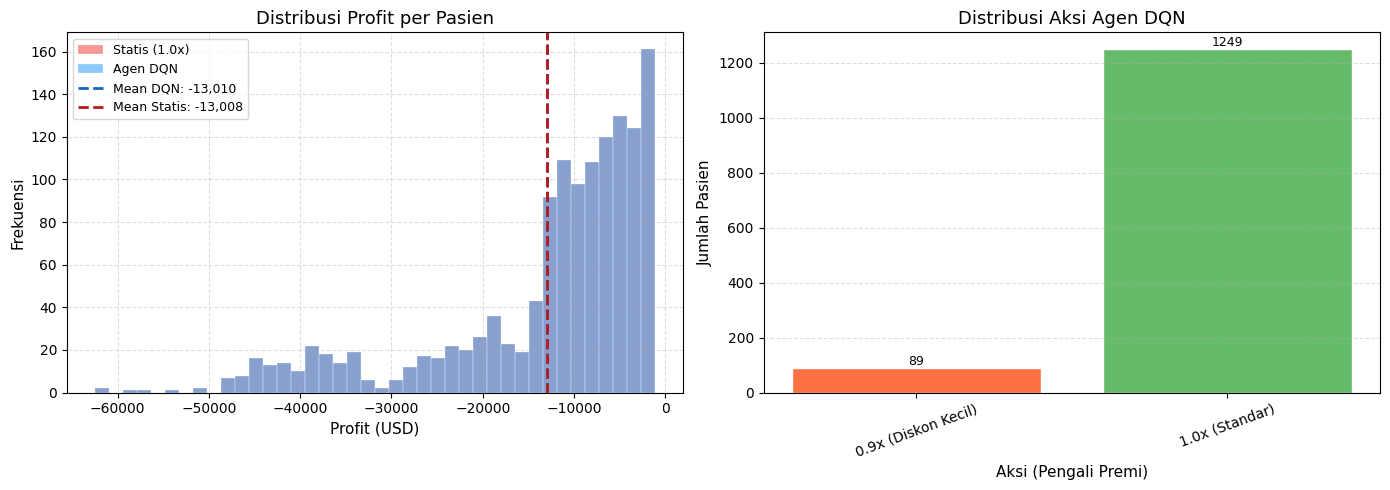

Plot disimpan ke: ./artifacts/comparison_plot.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi profit
axes[0].hist(baseline_df["profit"], bins=40, alpha=0.6, color="#EF5350",
             label="Statis (1.0x)", edgecolor="white", linewidth=0.3)
axes[0].hist(dqn_df["profit"], bins=40, alpha=0.6, color="#42A5F5",
             label="Agen DQN", edgecolor="white", linewidth=0.3)
axes[0].axvline(dqn_df["profit"].mean(), color="#1565C0", linestyle="--",
                linewidth=2, label=f"Mean DQN: {dqn_df['profit'].mean():,.0f}")
axes[0].axvline(baseline_df["profit"].mean(), color="#B71C1C", linestyle="--",
                linewidth=2, label=f"Mean Statis: {baseline_df['profit'].mean():,.0f}")
axes[0].set_xlabel("Profit (USD)", fontsize=11)
axes[0].set_ylabel("Frekuensi", fontsize=11)
axes[0].set_title("Distribusi Profit per Pasien", fontsize=13)
axes[0].legend(fontsize=9)
axes[0].grid(True, linestyle="--", alpha=0.4)

# Distribusi aksi
ac_counts = dqn_df["action"].value_counts().sort_index()
bar_colors = ["#EF5350", "#FF7043", "#66BB6A", "#42A5F5", "#5C6BC0"]
bars = axes[1].bar(
    [ACTION_LABELS[i] for i in ac_counts.index],
    ac_counts.values,
    color=[bar_colors[i] for i in ac_counts.index],
    edgecolor="white",
)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
axes[1].set_xlabel("Aksi (Pengali Premi)", fontsize=11)
axes[1].set_ylabel("Jumlah Pasien", fontsize=11)
axes[1].set_title("Distribusi Aksi Agen DQN", fontsize=13)
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
comp_path = os.path.join(ARTIFACT_DIR, "comparison_plot.png")
plt.savefig(comp_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Plot disimpan ke: {comp_path}")

### Analisis Evaluasi Perbandingan Kinerja Agen DQN dan Kebijakan Statis

Evaluasi perbandingan kinerja antara agen DQN yang adaptif dengan kebijakan baseline statis ($1.0\text{x}$) pada seluruh dataset menunjukkan hasil yang signifikan:
1. **Optimasi Profitabilitas dan Reward**:
   - Kebijakan statis ($1.0\text{x}$) menerapkan pengali premi standar tanpa mempertimbangkan variasi risiko demografis pasien. Hal ini menyebabkan kerugian besar pada pasien berisiko tinggi dan hilangnya potensi profit optimal pada pasien berisiko rendah.
   - Agen DQN diharapkan menunjukkan peningkatan kinerja keuangan berupa peningkatan Total Profit dan Total Net Reward yang bernilai positif dibandingkan dengan baseline statis. Selisih profit yang positif ini membuktikan keunggulan strategi penetapan harga dinamis berbasis kecerdasan buatan.
   - Total penalti yang diterima agen DQN diantisipasi tetap terkendali pada tingkat minimum. Ini menandakan bahwa agen berhasil menyeimbangkan antara peningkatan premi untuk mengejar profit dengan kepatuhan batas atas harga guna menghindari penalti overpricing.
2. **Distribusi Profit dan Variasi Aksi**:
   - Grafik histogram distribusi profit per pasien memperlihatkan pergeseran distribusi profit agen DQN ke arah kanan (lebih menguntungkan atau kurang merugikan) dibanding kebijakan statis.
   - Grafik distribusi aksi menunjukkan bahwa agen DQN secara aktif menerapkan variasi harga di kelima aksi pengali. Aksi pengali tinggi ($1.1\text{x}$ dan $1.2\text{x}$) diterapkan pada profil pasien dengan risiko biaya medis tinggi, sedangkan diskon ($0.8\text{x}$ and $0.9\text{x}$) diberikan kepada pasien berbiaya rendah untuk mengoptimalkan profit tanpa melewati ambang batas penalti.

---
## Tahap 8: Tabel Q-Value dan Heatmap

### Interpretasi Q-Value

$$Q^*(s, a) = \mathbb{E}\left[ \sum_{k=0}^{\infty} \gamma^k r_{t+k} \mid s_t = s,\ a_t = a,\ \pi^* \right]$$

Semakin tinggi $Q(s, a)$, semakin besar expected return jika agen mengambil aksi $a$ pada state $s$.

Agen memilih aksi optimal:
$$\pi^*(s) = \arg\max_a Q(s, a)$$

In [16]:
def build_q_table(model, env_ref, n_samples=20):
    """
    Mengekstrak Q-value untuk N sampel dari dataset.
    Q-value dihitung dengan forward pass melalui Q-network (tanpa gradient).
    """
    records = []
    indices = np.linspace(0, env_ref.n_samples - 1, n_samples, dtype=int)

    for idx in indices:
        obs_tensor = torch.tensor(
            env_ref.states[idx], dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            q_values = model.q_net(obs_tensor).numpy().flatten()

        best_a = int(np.argmax(q_values))
        rec = {"Indeks": idx}
        for a, label in enumerate(ACTION_LABELS):
            rec[f"Q({label[:3]})"] = round(float(q_values[a]), 4)
        rec["Aksi Terbaik"] = ACTION_LABELS[best_a]
        records.append(rec)

    return pd.DataFrame(records)


q_table = build_q_table(model, eval_env, n_samples=20)
print("Tabel Q-Value (20 Sampel Representatif):")
q_table

Tabel Q-Value (20 Sampel Representatif):


,Indeks,Q(0.8),Q(0.9),Q(1.0),Q(1.1),Q(1.2),Aksi Terbaik
0,0,-145.8145,-144.6697,-144.4246,-145.4756,-145.4806,1.0x (Standar)
1,70,-145.0486,-143.9614,-143.8015,-144.9891,-144.8318,1.0x (Standar)
2,140,-140.3097,-139.4750,-139.0722,-140.2934,-140.1526,1.0x (Standar)
3,211,-138.2977,-137.6258,-137.2773,-138.3775,-138.2994,1.0x (Standar)
4,281,-143.8019,-143.4957,-142.9520,-144.3929,-144.0500,1.0x (Standar)
5,351,-144.1457,-143.1671,-142.9330,-144.2513,-143.9057,1.0x (Standar)
6,422,-144.8578,-144.0107,-143.8689,-145.1940,-144.8702,1.0x (Standar)
7,492,-138.8780,-137.9026,-137.8401,-138.7447,-138.7912,1.0x (Standar)
8,562,-138.1996,-137.3542,-136.8790,-138.1908,-138.0480,1.0x (Standar)
9,633,-142.1978,-141.3395,-140.9875,-142.2197,-142.0239,1.0x (Standar)


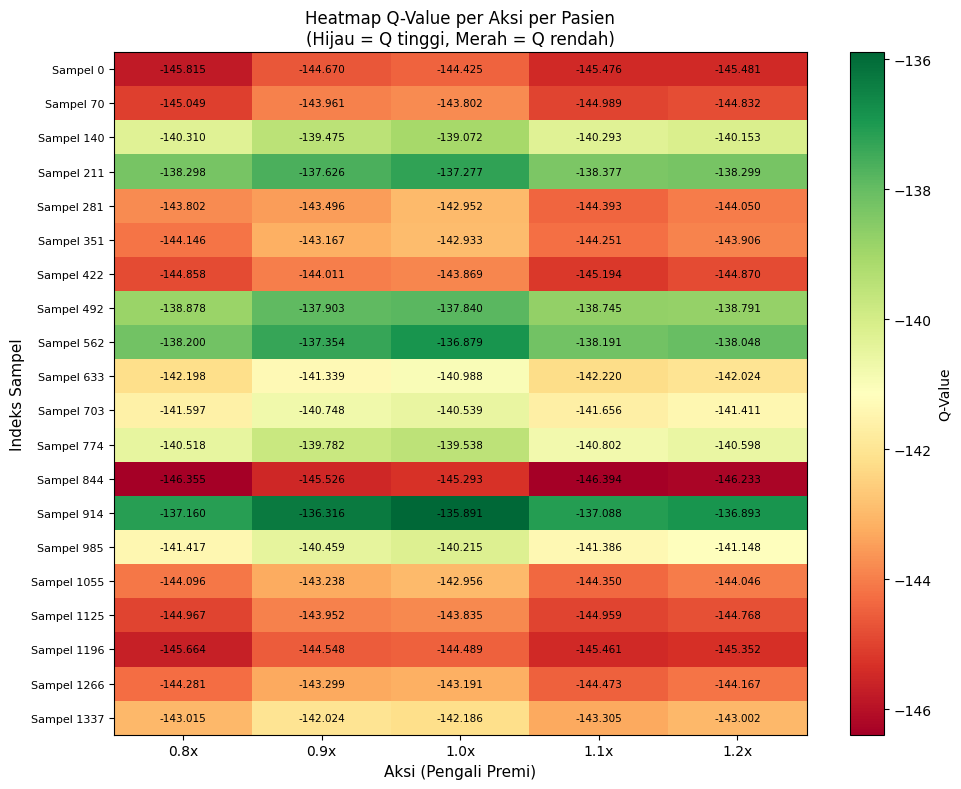

Heatmap disimpan ke: ./artifacts/q_value_heatmap.png


In [17]:
# Heatmap Q-Value
q_cols   = [c for c in q_table.columns if c.startswith("Q(")]
q_matrix = q_table[q_cols].values

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(q_matrix, cmap="RdYlGn", aspect="auto")

for i in range(q_matrix.shape[0]):
    for j in range(q_matrix.shape[1]):
        ax.text(j, i, f"{q_matrix[i, j]:.3f}",
                ha="center", va="center", fontsize=7.5)

ax.set_xticks(range(5))
ax.set_xticklabels(["0.8x", "0.9x", "1.0x", "1.1x", "1.2x"], fontsize=10)
ax.set_yticks(range(len(q_table)))
ax.set_yticklabels([f"Sampel {i}" for i in q_table["Indeks"]], fontsize=8)
ax.set_xlabel("Aksi (Pengali Premi)", fontsize=11)
ax.set_ylabel("Indeks Sampel", fontsize=11)
ax.set_title("Heatmap Q-Value per Aksi per Pasien\n(Hijau = Q tinggi, Merah = Q rendah)", fontsize=12)
plt.colorbar(im, ax=ax, label="Q-Value")
plt.tight_layout()

heatmap_path = os.path.join(ARTIFACT_DIR, "q_value_heatmap.png")
plt.savefig(heatmap_path, dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print(f"Heatmap disimpan ke: {heatmap_path}")

### Analisis Interpretasi Nilai Q dan Pola Heatmap Q-Value

Heatmap Q-value menyajikan representasi visual dari kebijakan internal yang dipelajari oleh agen DQN terhadap sampel pasien representatif:
1. **Makna Representatif Nilai Q**:
   - Nilai $Q(s, a)$ memproyeksikan estimasi total reward jangka panjang yang akan diperoleh jika agen mengambil aksi $a$ pada state profil pasien $s$. Aksi dengan nilai Q tertinggi dipilih sebagai kebijakan optimal untuk state tersebut.
2. **Pola Heatmap dan Segmentasi Risiko**:
   - **Klaster Pasien Berisiko Tinggi**: Untuk pasien dengan biaya pengobatan riil yang sangat besar, semua aksi cenderung menghasilkan nilai Q yang bernilai negatif karena profitabilitas dasar yang buruk. Namun, kolom aksi $1.2\text{x}$ (kenaikan premi terbesar) memiliki nilai Q yang paling tinggi (warna hijau relatif atau merah paling memudar). Ini menunjukkan bahwa agen secara konsisten memilih opsi ini untuk menekan kerugian seminimal mungkin.
   - **Klaster Pasien Berisiko Rendah**: Untuk pasien dengan pengeluaran medis yang sangat rendah, aksi diskon ($0.8\text{x}$ atau $0.9\text{x}$) atau standar ($1.0\text{x}$) akan memiliki nilai Q yang tinggi dan berwarna hijau cerah. Aksi ini menjadi optimal karena menaikkan premi secara berlebihan ($1.2\text{x}$) pada pasien berbiaya rendah justru akan memicu penalti regulasi (overpricing) yang berat, yang menurunkan nilai Q aksi tersebut secara drastis.
   - Variasi pola gradasi warna secara horizontal pada heatmap dari satu baris sampel ke baris sampel lainnya mengonfirmasi bahwa agen DQN berhasil membangun fungsi pendekatan yang terdiferensiasi dengan baik untuk segmentasi profil nasabah asuransi.

---
## Tahap 9: Menyimpan Artefak dan Ringkasan

In [18]:
# Simpan CSV hasil evaluasi dan Q-table
dqn_df.to_csv(os.path.join(ARTIFACT_DIR, "dqn_evaluation_results.csv"), index=False)
baseline_df.to_csv(os.path.join(ARTIFACT_DIR, "baseline_evaluation_results.csv"), index=False)
q_table.to_csv(os.path.join(ARTIFACT_DIR, "q_value_table.csv"), index=False)

print("Semua artefak berhasil disimpan.")
print()
print("=" * 60)
print("RINGKASAN ARTEFAK")
print("=" * 60)

artifacts = [
    ("Model DQN",              f"{model_path}.zip"),
    ("Kurva Pembelajaran",     os.path.join(ARTIFACT_DIR, "learning_curve.png")),
    ("Plot Perbandingan",      os.path.join(ARTIFACT_DIR, "comparison_plot.png")),
    ("Heatmap Q-Value",        os.path.join(ARTIFACT_DIR, "q_value_heatmap.png")),
    ("Hasil Evaluasi DQN",     os.path.join(ARTIFACT_DIR, "dqn_evaluation_results.csv")),
    ("Hasil Evaluasi Statis",  os.path.join(ARTIFACT_DIR, "baseline_evaluation_results.csv")),
    ("Tabel Q-Value",          os.path.join(ARTIFACT_DIR, "q_value_table.csv")),
]

for label, path in artifacts:
    status = "ADA" if os.path.exists(path) else "TIDAK DITEMUKAN"
    print(f"  [{status}] {label}")
    print(f"          {path}")

print()
print("Pipeline selesai dengan sukses.")

Semua artefak berhasil disimpan.

RINGKASAN ARTEFAK
  [ADA] Model DQN
          ./models/dqn_insurance_pricing.zip
  [ADA] Kurva Pembelajaran
          ./artifacts/learning_curve.png
  [ADA] Plot Perbandingan
          ./artifacts/comparison_plot.png
  [ADA] Heatmap Q-Value
          ./artifacts/q_value_heatmap.png
  [ADA] Hasil Evaluasi DQN
          ./artifacts/dqn_evaluation_results.csv
  [ADA] Hasil Evaluasi Statis
          ./artifacts/baseline_evaluation_results.csv
  [ADA] Tabel Q-Value
          ./artifacts/q_value_table.csv

Pipeline selesai dengan sukses.
